In [1]:
import os
import shutil
import random

# ========================
# 1. Define Dataset Paths
# ========================

brain_tumor_paths = {
    "Normal": "/kaggle/input/multibraindisease/archive (16)/Data/Normal",
    "Glioma": "/kaggle/input/multibraindisease/archive (16)/Data/Tumor/glioma_tumor",
    "Meningioma": "/kaggle/input/multibraindisease/archive (16)/Data/Tumor/meningioma_tumor",
    "Pituitary": "/kaggle/input/multibraindisease/archive (16)/Data/Tumor/pituitary_tumor"
}

alz_paths = {
    "MildDemented": "/kaggle/input/multibraindisease/archive (17)/AugmentedAlzheimerDataset/MildDemented",
    "ModerateDemented": "/kaggle/input/multibraindisease/archive (17)/AugmentedAlzheimerDataset/ModerateDemented",
    "NonDemented": "/kaggle/input/multibraindisease/archive (17)/AugmentedAlzheimerDataset/NonDemented",
    "VeryMildDemented": "/kaggle/input/multibraindisease/archive (17)/AugmentedAlzheimerDataset/VeryMildDemented"
}

ms_paths = {
    "Control_Axial": "/kaggle/input/multibraindisease/archive (18)/MS/Control Axial_crop",
    "Control_Saggital": "/kaggle/input/multibraindisease/archive (18)/MS/Control Saggital_crop",
    "MS_Axial": "/kaggle/input/multibraindisease/archive (18)/MS/MS Axial_crop",
    "MS_Saggital": "/kaggle/input/multibraindisease/archive (18)/MS/MS Saggital_crop"
}

# ========================
# 2. Create Output Folder
# ========================
output_dir = "/kaggle/working/Combined_Brain_Dataset_1000"
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir, exist_ok=True)

# ========================
# 3. Copy & Balance Function
# ========================
def copy_and_balance(class_name, src_folder, dest_root, target_count=1000):
    dest_folder = os.path.join(dest_root, class_name)
    os.makedirs(dest_folder, exist_ok=True)
    
    files = os.listdir(src_folder)
    copied = 0
    
    # If enough images, just sample 1000
    if len(files) >= target_count:
        files_sample = random.sample(files, target_count)
        for f in files_sample:
            shutil.copy(os.path.join(src_folder, f), os.path.join(dest_folder, f))
        copied = target_count
    else:
        # Not enough images → copy all & then oversample randomly
        for f in files:
            shutil.copy(os.path.join(src_folder, f), os.path.join(dest_folder, f))
        copied = len(files)
        
        # Oversample
        while copied < target_count:
            f = random.choice(files)  # duplicate random file
            new_name = f"dup_{copied}_{f}"
            shutil.copy(os.path.join(src_folder, f), os.path.join(dest_folder, new_name))
            copied += 1

# ========================
# 4. Balance All Classes
# ========================
all_paths = {**brain_tumor_paths, **alz_paths, **ms_paths}

for label, path in all_paths.items():
    copy_and_balance(label, path, output_dir, target_count=1000)

# ========================
# 5. Final Check
# ========================
final_counts = {cls: len(os.listdir(os.path.join(output_dir, cls))) for cls in os.listdir(output_dir)}
print("\nBalanced class distribution (1000 each):\n", final_counts)



Balanced class distribution (1000 each):
 {'MS_Axial': 1000, 'MS_Saggital': 1000, 'Normal': 1000, 'Glioma': 1000, 'NonDemented': 1000, 'Control_Saggital': 1000, 'Control_Axial': 1000, 'Meningioma': 1000, 'MildDemented': 1000, 'VeryMildDemented': 1000, 'ModerateDemented': 1000, 'Pituitary': 1000}


2025-08-31 17:21:02.993736: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756660863.171097      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756660863.221808      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


✅ Dataset split into train/val/test
Found 8400 images belonging to 12 classes.
Found 2400 images belonging to 12 classes.
Found 1200 images belonging to 12 classes.


I0000 00:00:1756660876.955412      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │        49,164 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

Epoch 1/20


I0000 00:00:1756660883.082594     120 service.cc:148] XLA service 0x7f80bc00f7f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1756660883.083388     120 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1756660883.664579     120 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/263 ━━━━━━━━━━━━━━━━━━━━ 45:04 10s/step - accuracy: 0.0625 - loss: 2.4848

I0000 00:00:1756660889.445922     120 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


263/263 ━━━━━━━━━━━━━━━━━━━━ 120s 417ms/step - accuracy: 0.1977 - loss: 2.0845 - val_accuracy: 0.4467 - val_loss: 1.2067
Epoch 2/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 104s 397ms/step - accuracy: 0.4534 - loss: 1.2193 - val_accuracy: 0.5417 - val_loss: 1.0229
Epoch 3/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 105s 401ms/step - accuracy: 0.5435 - loss: 1.0592 - val_accuracy: 0.6087 - val_loss: 0.8731
Epoch 4/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 104s 395ms/step - accuracy: 0.5845 - loss: 0.9615 - val_accuracy: 0.6629 - val_loss: 0.7798
Epoch 5/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 104s 395ms/step - accuracy: 0.6603 - loss: 0.8018 - val_accuracy: 0.7262 - val_loss: 0.6525
Epoch 6/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 104s 397ms/step - accuracy: 0.6718 - loss: 0.7190 - val_accuracy: 0.7504 - val_loss: 0.5837
Epoch 7/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 104s 396ms/step - accuracy: 0.7247 - loss: 0.6403 - val_accuracy: 0.7487 - val_loss: 0.5969
Epoch 8/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 106s 404ms/step - accuracy: 0.7341 - loss: 0.60

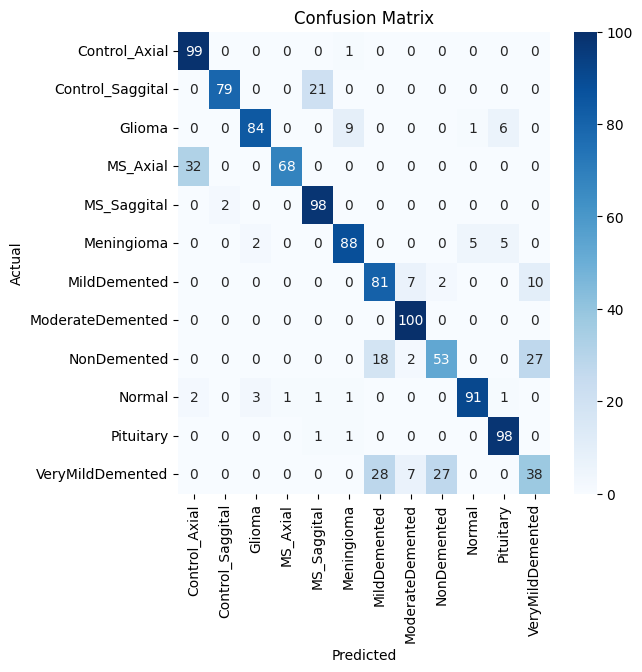

Classification Report:
                   precision    recall  f1-score   support

   Control_Axial       0.74      0.99      0.85       100
Control_Saggital       0.98      0.79      0.87       100
          Glioma       0.94      0.84      0.89       100
        MS_Axial       0.99      0.68      0.80       100
     MS_Saggital       0.81      0.98      0.89       100
      Meningioma       0.88      0.88      0.88       100
    MildDemented       0.64      0.81      0.71       100
ModerateDemented       0.86      1.00      0.93       100
     NonDemented       0.65      0.53      0.58       100
          Normal       0.94      0.91      0.92       100
       Pituitary       0.89      0.98      0.93       100
VeryMildDemented       0.51      0.38      0.43       100

        accuracy                           0.81      1200
       macro avg       0.82      0.81      0.81      1200
    weighted avg       0.82      0.81      0.81      1200



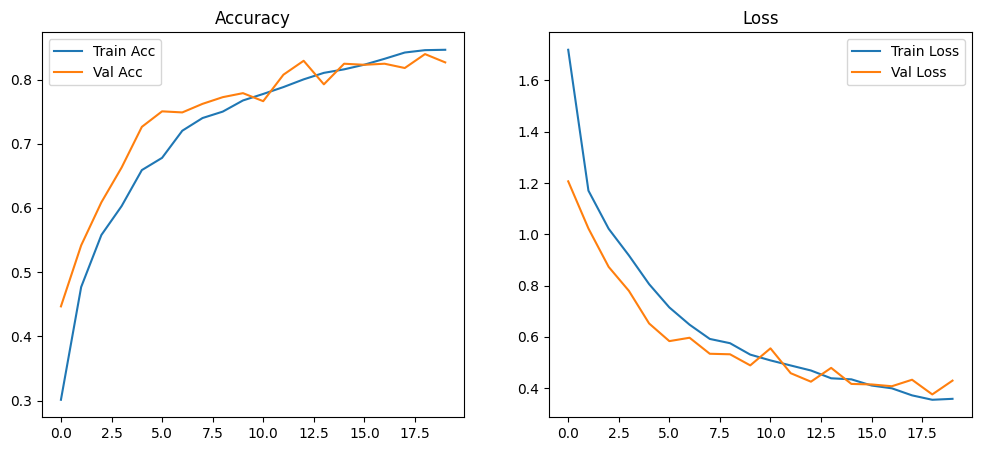

In [2]:
# =========================
# 1. Imports
# =========================
import os, shutil, warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

# =========================
# 2. Dataset Split
# =========================
data_root = "/kaggle/working/Combined_Brain_Dataset_1000"
base_dir  = "/kaggle/working/Combined_Brain_Dataset_1000_split"

train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")
test_dir  = os.path.join(base_dir, "test")

for folder in [train_dir, val_dir, test_dir]:
    os.makedirs(folder, exist_ok=True)

train_split, val_split = 0.7, 0.2  # test will be 0.1

for cls in os.listdir(data_root):
    cls_path = os.path.join(data_root, cls)
    if not os.path.isdir(cls_path): continue
    
    images = os.listdir(cls_path)
    
    train_files, test_files = train_test_split(images, test_size=0.3, random_state=42)
    val_files, test_files   = train_test_split(test_files, test_size=0.333, random_state=42)
    
    for split, files in zip([train_dir, val_dir, test_dir], [train_files, val_files, test_files]):
        os.makedirs(os.path.join(split, cls), exist_ok=True)
        for f in files:
            shutil.copy(os.path.join(cls_path, f), os.path.join(split, cls, f))

print("✅ Dataset split into train/val/test")

# =========================
# 3. Data Generators
# =========================
img_size = (227, 227)  # AlexNet input size
batch_size = 32

train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True, rotation_range=20, zoom_range=0.2)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(train_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical')
val_gen   = val_datagen.flow_from_directory(val_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical')
test_gen  = test_datagen.flow_from_directory(test_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False)

num_classes = len(train_gen.class_indices)

# =========================
# 4. AlexNet Model
# =========================
model = Sequential([
    Conv2D(96, (11,11), strides=4, activation='relu', input_shape=(227,227,3)),
    MaxPooling2D((3,3), strides=2),
    Conv2D(256, (5,5), padding="same", activation='relu'),
    MaxPooling2D((3,3), strides=2),
    Conv2D(384, (3,3), padding="same", activation='relu'),
    Conv2D(384, (3,3), padding="same", activation='relu'),
    Conv2D(256, (3,3), padding="same", activation='relu'),
    MaxPooling2D((3,3), strides=2),
    Flatten(),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

# =========================
# 5. Training
# =========================
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    verbose=1
)

# =========================
# 6. Evaluation
# =========================
loss, acc = model.evaluate(test_gen)
print(f"✅ Test Accuracy: {acc*100:.2f}%")

# Confusion Matrix
y_pred = np.argmax(model.predict(test_gen), axis=1)
cm = confusion_matrix(test_gen.classes, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=train_gen.class_indices.keys(), yticklabels=train_gen.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("Classification Report:\n", classification_report(test_gen.classes, y_pred, target_names=train_gen.class_indices.keys()))

# =========================
# 7. Training Curves
# =========================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.legend(), plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.legend(), plt.title("Loss")
plt.show()
